### Proyecto de Riesgo Crediticio

#### 1. Definición del problema

##### Objetivo del negocio

El objetivo del negocio es estimar la probabilidad de incumplimiento de un solicitante para apoyar la toma de decisiones en la aprobación de créditos.

##### Variable objetivo (loan_status)

La variable objetivo a predecir es 'loan_status'. Esta indica si el solicitante incumplió (default) o no con el pago del préstamo. Esta será la variable que el modelo intentará predecir.

##### Por qué predecir el incumplimiento

Predecir el incumplimiento permite a las entidades financieras evaluar el riesgo de cada solicitante antes de aprobar un préstamo. Esto facilita decisiones más informadas sobre la aprobación del crédito, las tasas de interés y los límites de financiamiento, reduciendo potenciales pérdidas por impago.

#### 2. Carga e inspección de los datos

In [46]:
import pandas as pd
import statistics as stat
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Carga del dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [48]:
# Tamaño del dataset
df.shape

(32581, 12)

In [49]:
# Variable target
print(df['loan_status'].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [50]:
# Verificamos el tipo de dato de cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [51]:
# Duplicados y vacíos
print('Duplicated values:',df.duplicated().sum())
print('Missing values: \n',df.isnull().sum())

Duplicated values: 165
Missing values: 
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


#### 3. EDA

##### Análisis univariado

In [52]:
# Variables numéricas
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


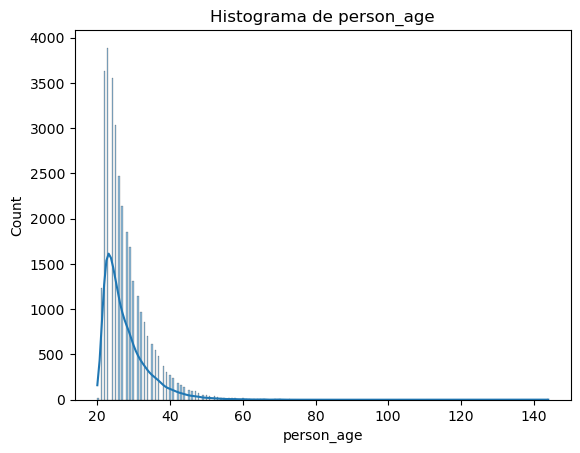

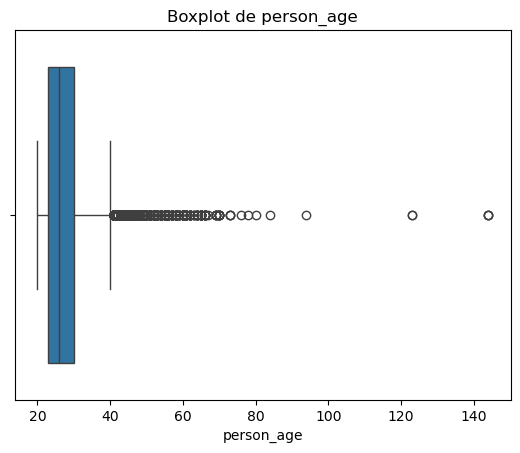

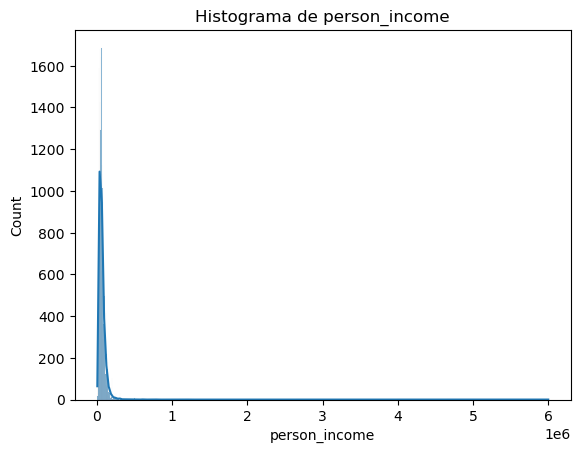

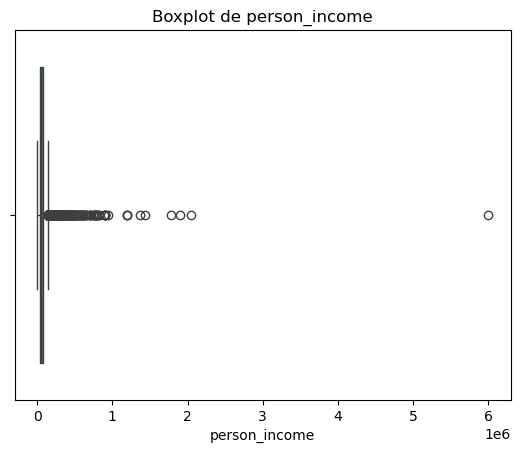

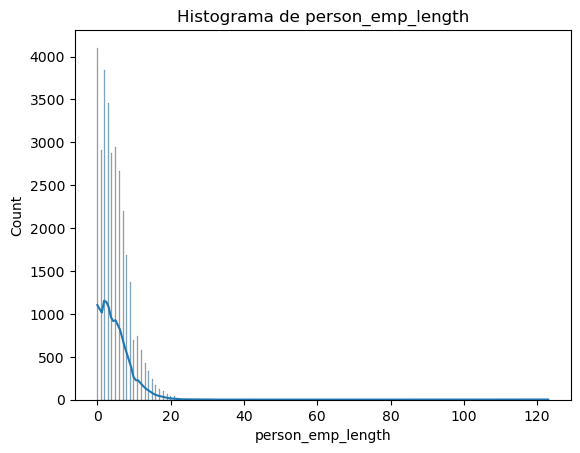

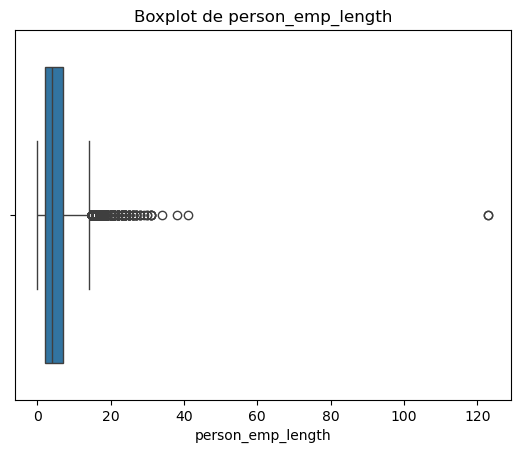

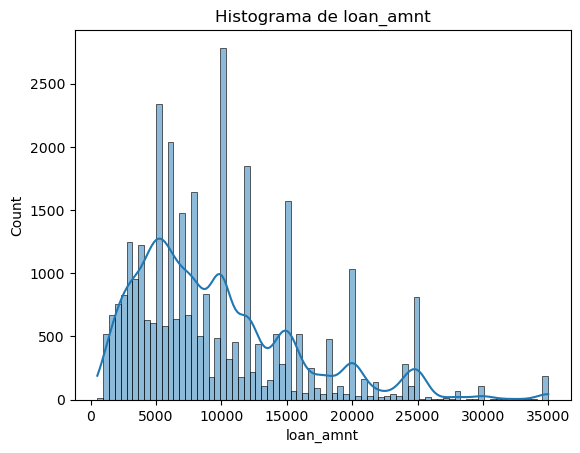

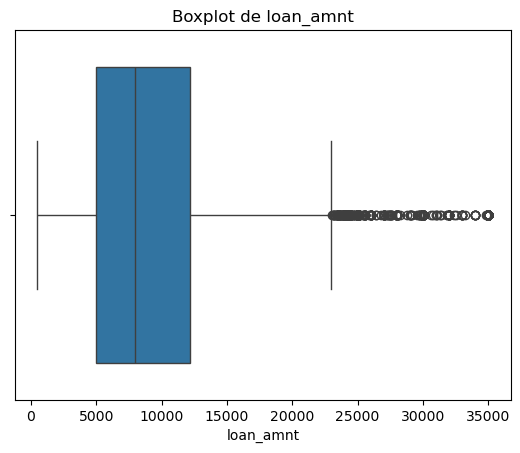

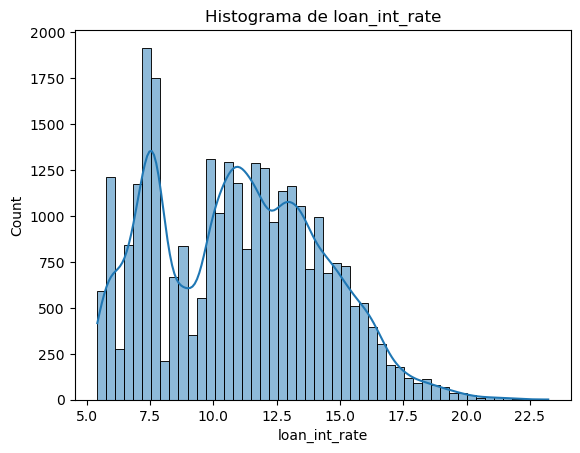

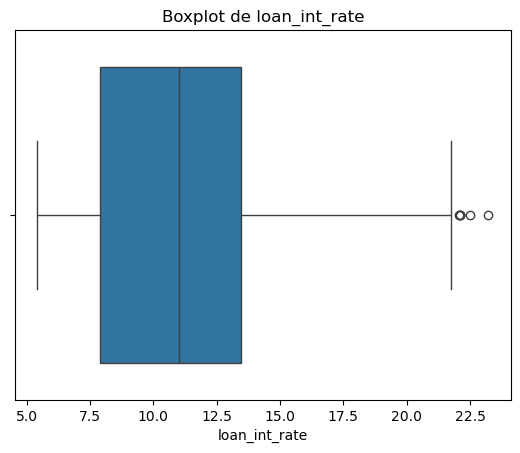

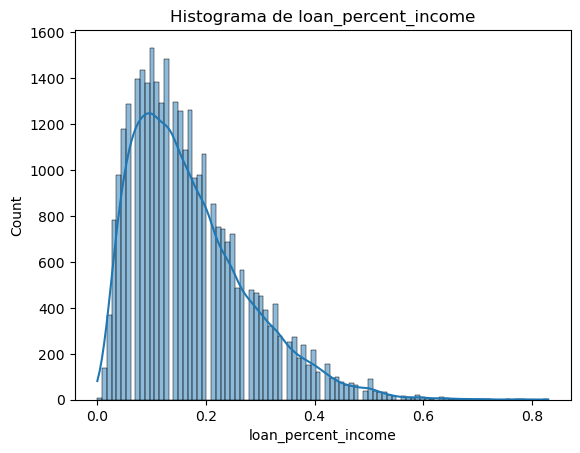

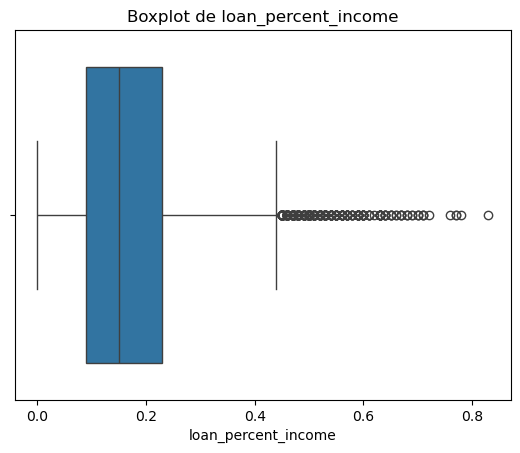

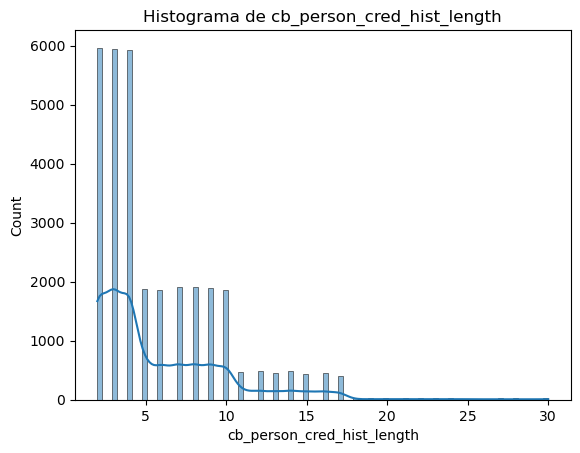

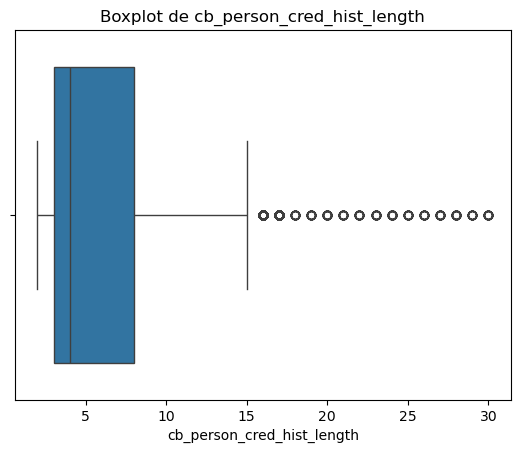

In [53]:
df_numerical = df.select_dtypes(include=['number'])
df_numerical = df_numerical.drop(columns='loan_status')
for columns in df_numerical.columns:
    # Histograma
    sns.histplot(df_numerical[columns], kde=True)
    plt.title(f'Histograma de {columns}')
    plt.show()
    
    # Boxplot
    sns.boxplot(x=df_numerical[columns])
    plt.title(f'Boxplot de {columns}')
    plt.show()

person_age

Según lo revisado, la mayoría de edad se concentra entre los 20 y 40 años. La distribución presenta una asimetría positiva donde se pueden observar edades muy poco realistas. Sin embargo, se puede observar que tanto la media como la mediana son parecidas.

person_income

Según lo revisado, la mayoría de personas perciben un ingreso similar que no supera el millón de dólares anuales. Sin embargo, existen ingresos extremadamente altos. En este caso, la media es significativamente mayor que la mediana.

person_emp_length

Según lo revisado, la mayoría de personas no pasan de los 20 años de experiencia. Aunque existen valores imposibles, la distribución se concentra en el primer grupo antes mencionado.

loan_amount

Según lo revisado, los préstamos varían, no hay una tendencia para una cantidad en específico, aunque sí se observa que hay una gran cantidad de préstamos altos, que representan outliers en la distribución, ya que está sesgada a la derecha.

loan_int_rate

Según lo revisado, no se presenta una alta concentración de tasas en un rango en específico, solo ligeramente en un 7.5%. Lo que sí se puede observar es que hay tasas extraordinariamente altas pero tampoco improbables, además de que la distribución es relativamente uniforme.

loan_percent_income

Según lo revisado, la mayoría de personas sacaron un préstamo que tiende a ser no mayor a la mitad de sus ingresos anuales, lo cual es correcto porque reduce el riesgo de impago. Sin embargo, sí hay un grupo que incluso llega hasta el 80% de sus ingresos.

cb_person_cred_hist_length

Según lo revisado, las personas no cuentan un historial crediticio mayor a 15 años, solo algunas y son muy pocas. Esto quiere indicar que la gran mayoría en el dataset son jóvenes. Igualmente, habría que validarlo porque a simple vista no coincide con las edades observadas.

                       Absolute   Relative
person_home_ownership                     
RENT                      16446  50.477272
MORTGAGE                  13444  41.263313
OWN                        2584   7.931003
OTHER                       107   0.328412


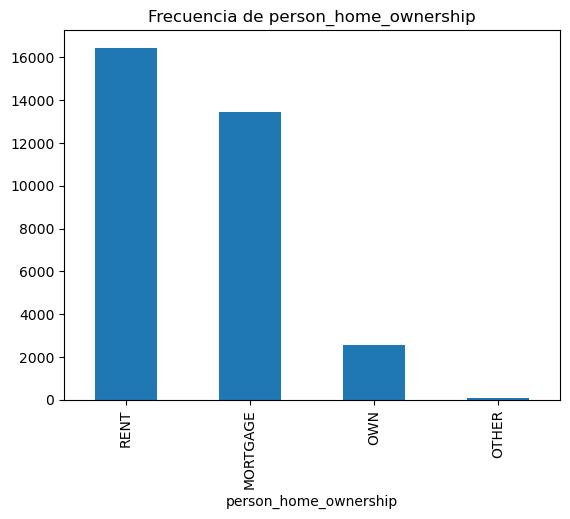

                   Absolute   Relative
loan_intent                           
EDUCATION              6453  19.806022
MEDICAL                6071  18.633559
VENTURE                5719  17.553175
PERSONAL               5521  16.945459
DEBTCONSOLIDATION      5212  15.997053
HOMEIMPROVEMENT        3605  11.064731


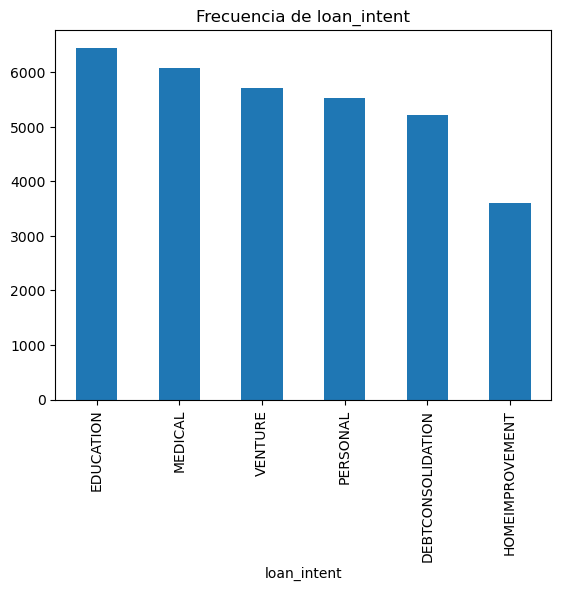

            Absolute   Relative
loan_grade                     
A              10777  33.077561
B              10451  32.076977
C               6458  19.821368
D               3626  11.129186
E                964   2.958780
F                241   0.739695
G                 64   0.196434


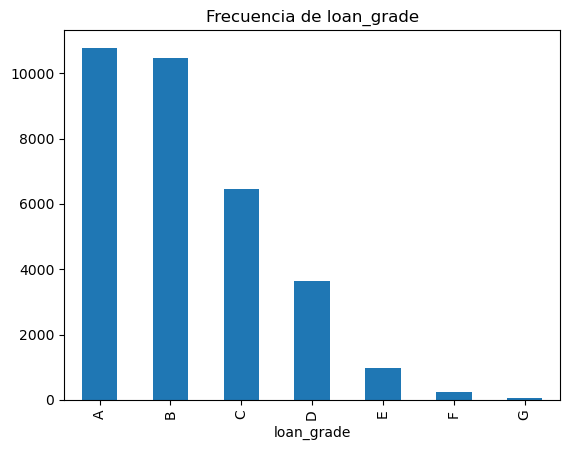

                           Absolute   Relative
cb_person_default_on_file                     
N                             26836  82.367024
Y                              5745  17.632976


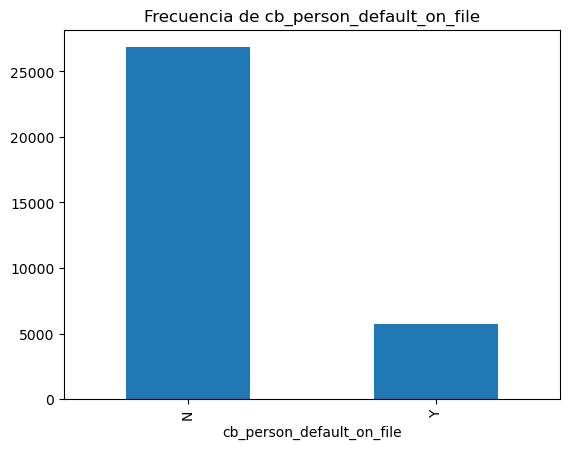

             Absolute   Relative
loan_status                     
0               25473  78.183604
1                7108  21.816396


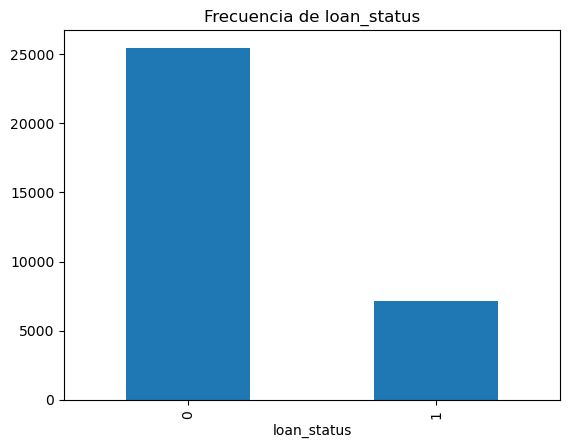

In [54]:
# Variables categóricas
df_categorical = list(df.select_dtypes(include=['object']).columns)
df_categorical.append('loan_status')
for columns in df_categorical:
    # Frecuencia relativa y absoluta
    fa = df[columns].value_counts()
    fr = df[columns].value_counts(normalize=True)*100
    frequency_table = pd.DataFrame({'Absolute': fa, 'Relative': fr})
    print(frequency_table)

    # Barplot
    fa.plot(kind='bar', title=f"Frecuencia de {columns}")
    plt.show()

person_home_ownership

Según lo observado, las categorías dominantes son la de RENT y MORTGAGE. Esto tiene sentido ya que estos dos casos tienden a generar más deuda por pagar, que los que tienen su propia casa u otros casos.

loan_intent

Según lo observado, si bien el motivo con mayor número de deudores, no es el principal, ya que no hay una gran distribución entre los demás. Esto quiere decir que la cartera está compuesta de diferentes tipos de deudores.

loan_grade

Según lo observado, la cartera crediticia está compuesta principalmente por deudores que presentan un riesgo de pago mínimo para el banco. A diferencia del grado más alto con mayor riesgo de default, el cual no llega ni al 0.2% de la base total de deudores.

cb_person_default_on_file

Según lo observado, podemos interpretar que la cartera crediticia de esta base no presenta antecendentes de incumplimiento de pago. Incluso podemos o observar que los que sí tienen antecedentes son casi una quinta parte del total.

loan_status

Según lo observado, más de la tercera parte de los deudores de la base no presentan un incumpliento de pago. Por un lado, esto demuestra que la gran mayoría cumple con pagar su deuda, pero por el otro, representa un claro desbalance en la calidad de los datos.

##### Análisis bivariado

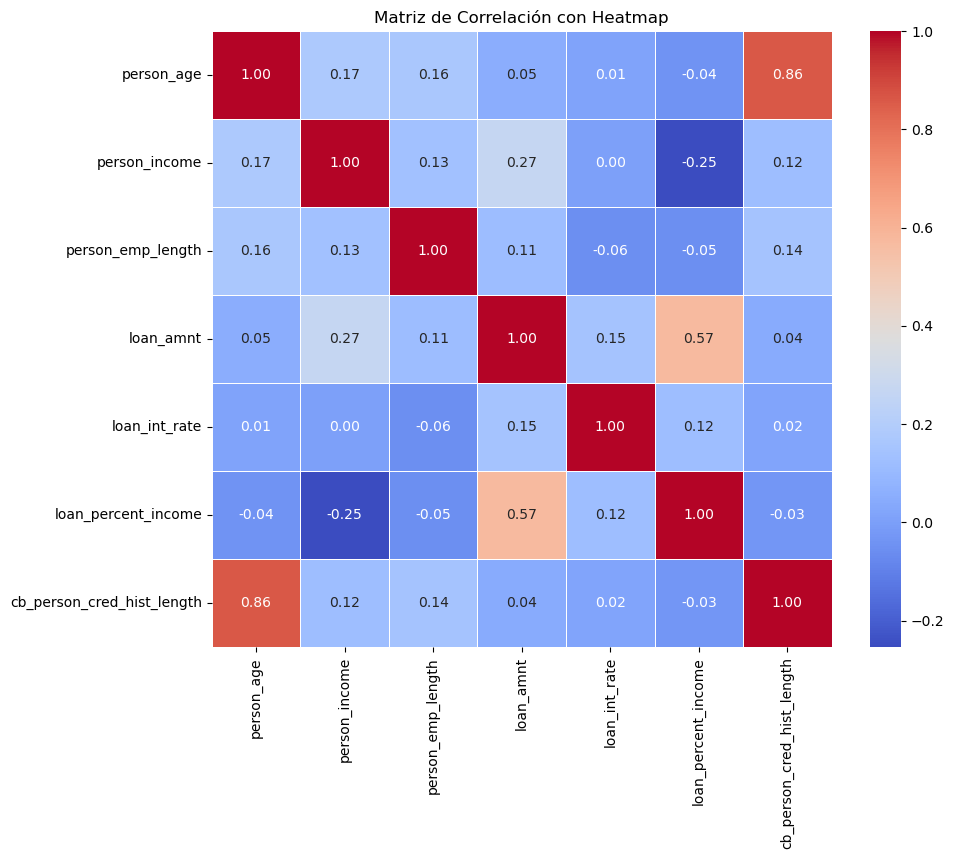

In [55]:
# Numérica vs Numérica
matriz_corr = df_numerical.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación con Heatmap")
plt.show()

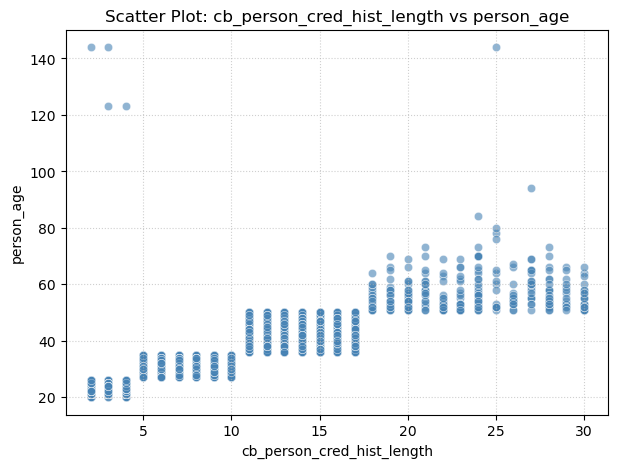

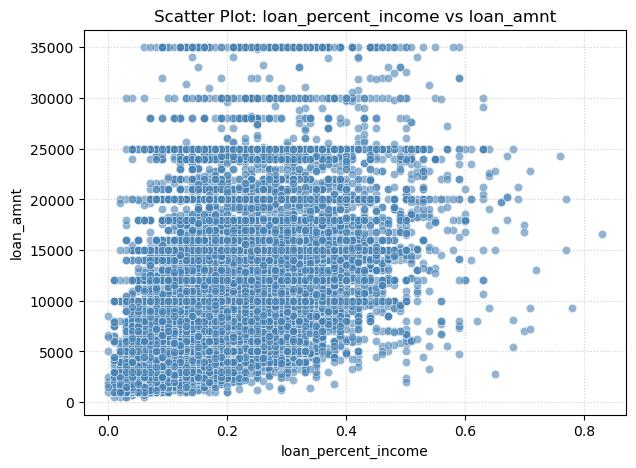

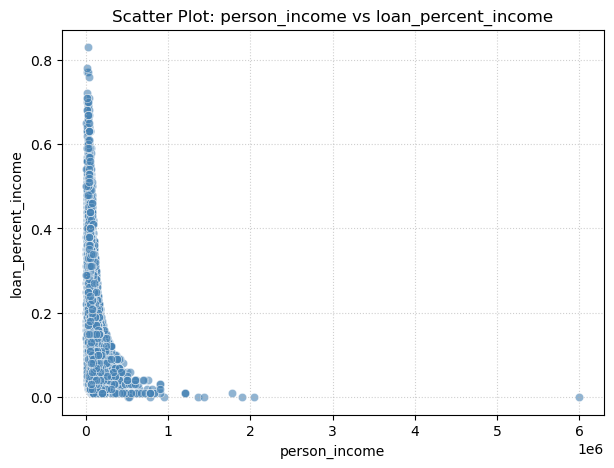

In [56]:
# Relacionas más interesantes
relaciones_nvsn= [
    ('cb_person_cred_hist_length', 'person_age'), # Tupla 1
    ('loan_percent_income', 'loan_amnt'), # Tupla 2
    ('person_income','loan_percent_income') # Tupla 3
]

for x_col, y_col in relaciones_nvsn:
    
    plt.figure(figsize=(7, 5))
    
    # Scatter plot
    sns.scatterplot(data=df_numerical, x=x_col, y=y_col, alpha=0.6, color='steelblue')
    plt.title(f'Scatter Plot: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27752\1078618829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


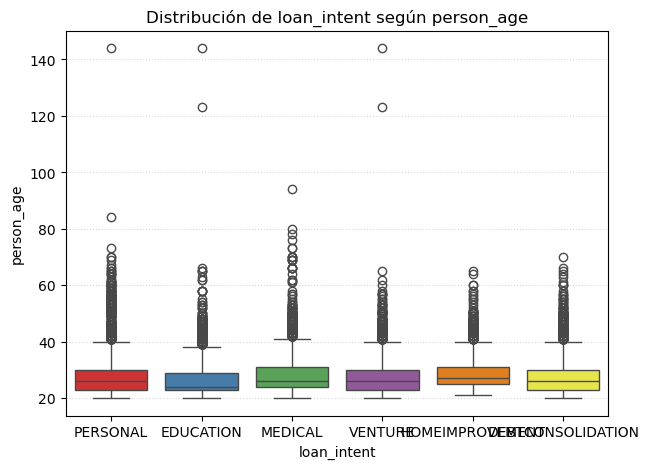

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27752\1078618829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


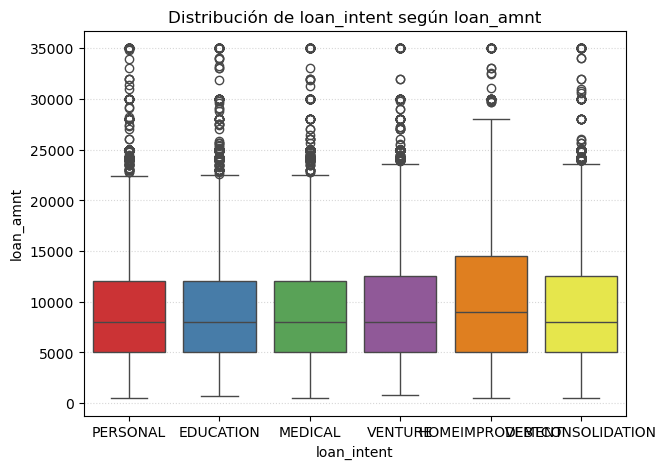

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27752\1078618829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


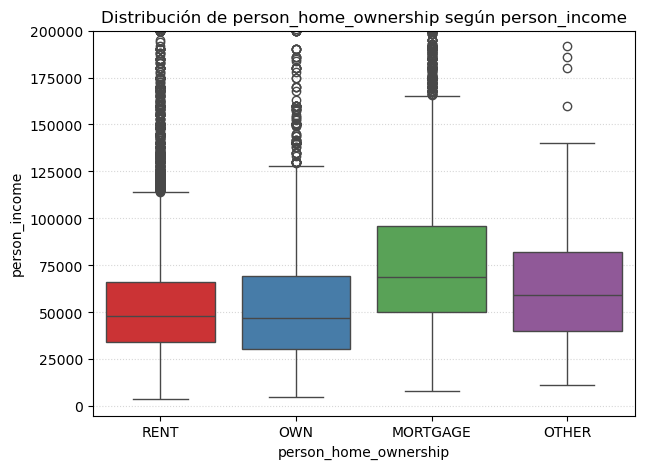

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27752\1078618829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


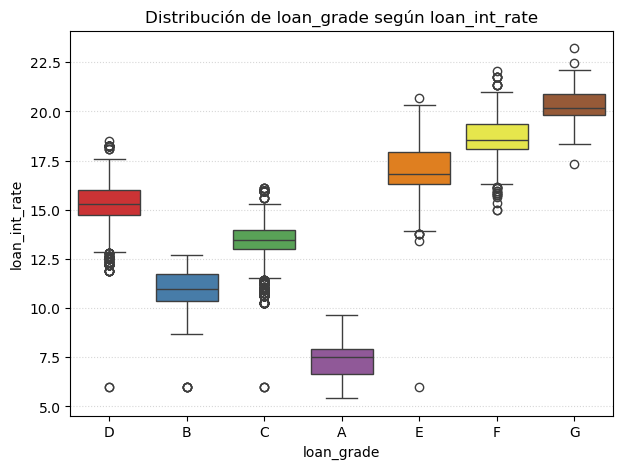

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27752\1078618829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


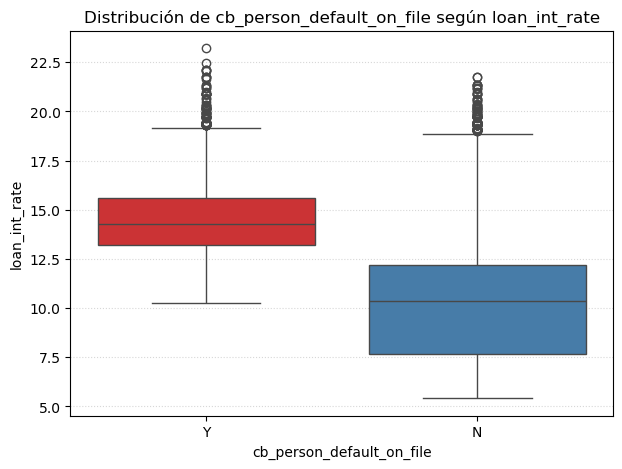

In [61]:
# Categórica vs Numérica

relaciones_cvsn= [
    ('loan_intent', 'person_age'), # Tupla 1
    ('loan_intent', 'loan_amnt'), # Tupla 2
    ('person_home_ownership','person_income'), # Tupla 3
    ('loan_grade','loan_int_rate'), # Tupla 4
    ('cb_person_default_on_file','loan_int_rate') # Tupla 5
]

for x_col, y_col in relaciones_cvsn:
    
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
    data=df, 
    x=x_col,
    y=y_col,
    palette='Set1'
    )
    
    if 'person_income' in (x_col, y_col):
        plt.ylim(-5000, 200000)

    plt.title(f'Distribución de {x_col} según {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.show()

In [ ]:
# Categórica vs Categórica

In [ ]:
# Variable objetivo

###########################

In [ ]:
df_mode_home_ownership = stat.mode(df['person_home_ownership'])
df_mode_home_ownership

'RENT'

In [ ]:
df_mode_loan_intent = stat.mode(df['loan_intent'])
df_mode_loan_intent

'EDUCATION'

In [ ]:
df_mean_loan_amount = df['loan_amnt'].mean()
df_mean_loan_amount

9589.371105859243

In [ ]:
mean_age_education = df.loc[df['loan_intent'] == 'EDUCATION', 'person_age'].mean()
mean_age_education

26.588098558809858

In [ ]:
mode_home_ownership = stat.mode(df.loc[df['loan_intent'] == 'EDUCATION', 'person_home_ownership'])
mode_home_ownership

'RENT'

In [ ]:
ratio_education_rent = len(df[(df['loan_intent'] == 'EDUCATION') & (df['person_home_ownership'] == 'RENT')])/len(df[df['loan_intent'] == 'EDUCATION'])
ratio_education_rent

0.5084456841779017

In [ ]:
education_rent = df[(df['loan_intent'] == 'EDUCATION') & (df['person_home_ownership'] == 'RENT')]
education_rent.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,3281.000000,3.281000e+03,3225.000000,3281.000000,2974.000000,3281.000000,3281.000000,3281.000000
mean,26.447120,5.469374e+04,3.680310,8714.256324,11.292105,0.262115,0.179326,5.111247
std,6.068689,4.594763e+04,3.238043,5767.606595,3.106259,0.439852,0.107174,3.742488
min,20.000000,4.080000e+03,0.000000,700.000000,5.420000,0.000000,0.010000,2.000000
25%,23.000000,3.400000e+04,1.000000,4800.000000,8.880000,0.000000,0.100000,3.000000
50%,24.000000,4.700000e+04,3.000000,7500.000000,11.360000,0.000000,0.160000,4.000000
75%,28.000000,6.500000e+04,5.000000,11400.000000,13.490000,1.000000,0.240000,7.000000
max,123.000000,1.782000e+06,22.000000,35000.000000,21.740000,1.000000,0.770000,30.000000


In [ ]:
print(df['loan_intent'].value_counts())

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


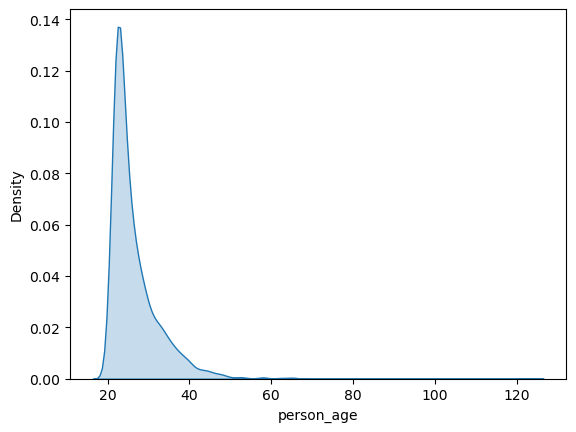

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dibuja solo la curva de distribución
sns.kdeplot(data=df[(df['loan_intent'] == 'EDUCATION') & (df['person_home_ownership'] == 'RENT')], x="person_age", fill=True)
plt.show()

In [ ]:
# Rango intercuartílico para la edad de las personas con préstamo educativo y propiedad de vivienda en alquiler

q1 = education_rent['person_age'].quantile(0.10)
q3 = education_rent['person_age'].quantile(0.90)
q1, q3

(22.0, 34.0)